In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import numpy as np

from functools import partial
from typing import NamedTuple

Array = jax.Array

Time homogeneous vs time inhomogeneous Markov Chains

In [ ]:
class StepState(NamedTuple):
    curr_rng: jrandom.PRNGKey
    done_t: Array
    curr_s: Array
    curr_transition: Array

@partial(jax.vmap, in_axes=[0, 0, None])
def sample_transition(rng, curr_s, transition):
    return jrandom.choice(
        rng,
        len(transition[curr_s]),
        p=transition[curr_s],
    )

def simulate(rng, transition, init_dist, num_samples, T, K, discounting):
    B = T * K

    @jax.jit
    def step(step_i, step_state):
        curr_s = step_state.curr_s
        curr_transition = step_state.curr_transition

        # TODO: Do this for more states
        curr_p = jax.lax.select(
            (step_i + 1) % T == 0,
            curr_transition[0, 0] * discounting,
            curr_transition[0, 0],
        )
        curr_transition = jnp.array([
            [curr_p, 1 - curr_p],
            [0.0, 1.0],
        ])

        done_t = step_state.done_t
        done_t = jax.lax.select(
            jnp.logical_and(
                curr_s == 1,
                jnp.logical_not(jnp.isfinite(done_t)),
            ),
            jnp.full_like(done_t, fill_value=step_i),
            done_t,
        )

        curr_rng = jrandom.fold_in(
            step_state.curr_rng,
            step_i,
        )
        curr_rng = jrandom.split(curr_rng, num_samples)

        next_s = sample_transition(
            curr_rng,
            curr_s,
            curr_transition,
        )

        return StepState(
            curr_rng=rng,
            done_t=done_t,
            curr_s=next_s,
            curr_transition=curr_transition,
        )

    init_state = jrandom.choice(
        rng,
        len(init_dist),
        p=init_dist,
        shape=(num_samples,),
    )

    return jax.lax.fori_loop(
        0,
        B,
        step,
        StepState(
            curr_rng=rng,
            done_t=np.full(num_samples, fill_value=jnp.nan),
            curr_s=init_state,
            curr_transition=transition,
        )
    )


In [3]:
seed = 42
num_samples = 1000

rng = jrandom.PRNGKey(seed)

# p_range = np.arange(0.8, 1.0, 0.005)
p_range = np.arange(0.0, 1.0, 0.05)
init_dist = np.array([1.0, 0.0])

In [4]:
all_res = {}

tk_pairs = (
    (1, 10),
    (2, 5),
    (5, 2),
    (10, 1),
)

discountings = (0.4, 0.5, 0.6, 0.7, 0.8, 0.9)

for discount_i, discounting in enumerate(discountings):
    all_res.setdefault(discounting, dict())
    for (T, K) in tk_pairs:
        all_res[discounting].setdefault((T, K), dict())
        for curr_p in p_range:
            curr_transition = np.array([
                [curr_p, 1.0 - curr_p],
                [0.0, 1.0],
            ])
            all_res[discounting][(T, K)][curr_p] = simulate(
                rng,
                curr_transition,
                init_dist,
                num_samples,
                T,
                K,
                discounting,
            )

(1, 10) [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
(2, 5) [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
(5, 2) [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         0.9990001  0.9990001  0.998
 0.99500006 0.99000007]
(10, 1) [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         0.9990001  0.994
 0.99200004 0.98       0.96000004 0.92100006 0.85800004 0.76000005
 0.59300005 0.384     ]
(1, 10) [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
(2, 5) [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
(5, 2) [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         0.998      0.99700004 0.99300003
 0.9850001  0.9760001 ]
(10, 1) [1.         1.         1.         1.         1.         1.
 1.     

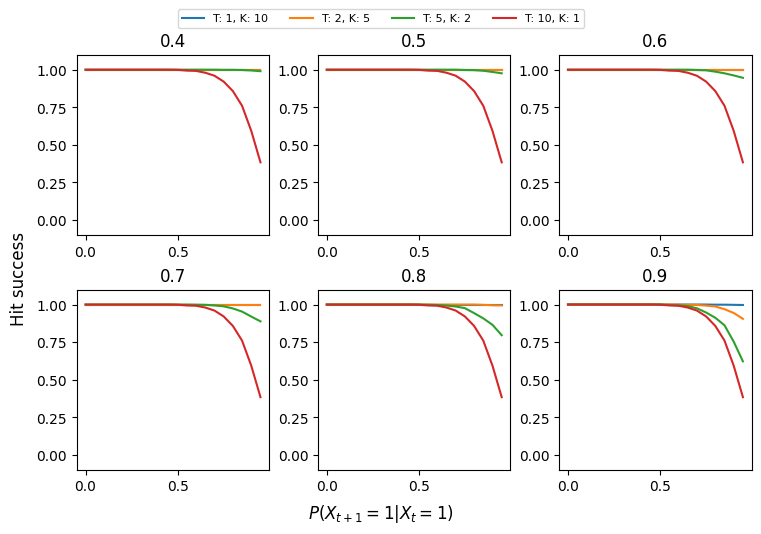

In [10]:
num_cols = 3
num_rows = int(np.ceil(len(discountings) / num_cols))
fig, axes = plt.subplots(
    num_rows,
    num_cols,
    layout="constrained",
    figsize=(2.5 * num_cols, 2.5 * num_rows),
)

axes = axes.flatten()
for discount_i, discounting in enumerate(discountings):
    ax = axes[discount_i]

    discount_res = all_res[discounting]
    for tk_pair, curr_res in discount_res.items():
        hit_success = np.array([
            np.mean(jnp.isfinite(curr_res[curr_p].done_t))
            for curr_p in p_range
        ])
        ax.plot(
            p_range,
            hit_success,
            label=f"T: {tk_pair[0]}, K: {tk_pair[1]}" if discount_i == 0 else ""
        )
        print(tk_pair, hit_success)
    ax.set_title(f"{discounting}")
    ax.set_ylim(-0.1, 1.1)

for i in range(len(discountings), len(axes)):
    fig.delaxes(axes[i])

fig.supxlabel("$P(X_{{t+1}} = 1 | X_t = 1)$")
fig.supylabel("Hit success")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

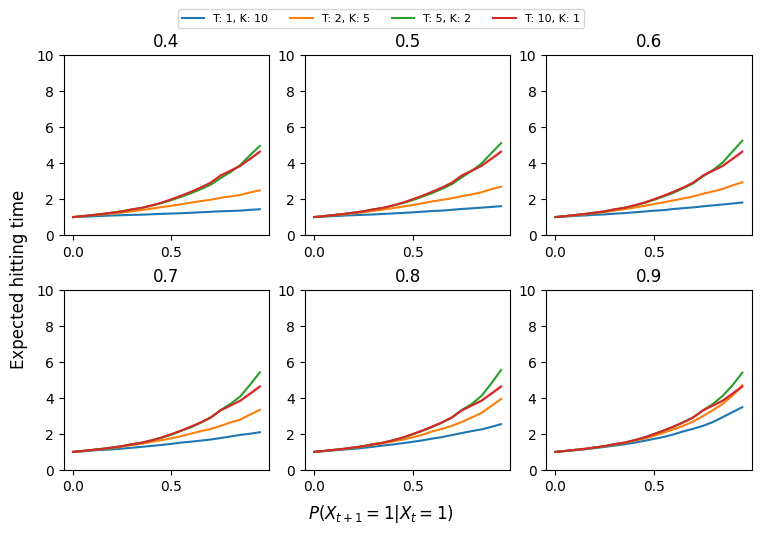

In [6]:
num_cols = 3
num_rows = int(np.ceil(len(discountings) / num_cols))
fig, axes = plt.subplots(
    num_rows,
    num_cols,
    layout="constrained",
    figsize=(2.5 * num_cols, 2.5 * num_rows),
)

axes = axes.flatten()
for discount_i, discounting in enumerate(discountings):
    ax = axes[discount_i]

    discount_res = all_res[discounting]
    for tk_pair, curr_res in discount_res.items():
        mean_hitting_time = np.array([
            jnp.nanmean(curr_res[curr_p].done_t)
            for curr_p in p_range
        ])
        std_hitting_time = np.array([
            jnp.nanstd(curr_res[curr_p].done_t)
            for curr_p in p_range
        ]) / jnp.sqrt(
            np.array([
                np.sum(jnp.isfinite(curr_res[curr_p].done_t))
                for curr_p in p_range
            ])
        )
        ax.plot(
            p_range,
            mean_hitting_time,
            label=f"T: {tk_pair[0]}, K: {tk_pair[1]}" if discount_i == 0 else ""
        )
        ax.fill_between(
            p_range,
            mean_hitting_time - std_hitting_time,
            mean_hitting_time + std_hitting_time,
            alpha=0.2,
        )
    ax.set_title(f"{discounting}")
    ax.set_ylim(0.0, T * K)

for i in range(len(discountings), len(axes)):
    fig.delaxes(axes[i])

fig.supxlabel("$P(X_{{t+1}} = 1 | X_t = 1)$")
fig.supylabel("Expected hitting time")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

In [6]:
def two_state_mean_ht(T, p):
    return (1 - (T + 1) * (p ** T) + T * (p ** (T + 1))) / ((1 - p) * (1 - p ** T))

In [8]:
T = 10
p = 0.5
two_state_mean_ht(T, p)

1.9902248289345064